<a href="https://colab.research.google.com/github/Olayisa/Olayisa/blob/main/Copy_of_Yisa_DLProject__CIFAR_10_classification_using_CNN_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Deep Learning NN Network Model_inporttensorflow as tf & from tensorflowimport keras,
Also, it required Comparisons and Deep Evaluation**

## Importing Libraries

In [ ]:
#Install Three fundamental libraries auspiciously
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#Because its deep learning NN network model - keras and tensorflow
import tensorflow as tf
from tensorflow import keras

#comparisons or evaluations by importing from sklearn.metrics_ConfussionMatrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix

## Load the data

In [ ]:
from keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


The CIFAR-10 dataset (Canadian Institute For Advanced Research) is a collection of images that are commonly used to train machine learning and computer vision algorithms. It is one of the most widely used datasets for machine learning research. The CIFAR-10 dataset contains 60,000 32x32 color images in 10 different classes. The 10 different classes represent airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks. There are 6,000 images of each class.

In [ ]:
# Checking the number of rows (records) and columns (features)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(X_train[0])

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [ ]:
import os
import pandas as pd
file_path = os.path.abspath(r'C:\Users\Olayi\DeepLearning')
print(file_path)
if os.path.exists(file_path):
       df = pd.read_csv(file_path)
       df.head()
else:
       print(f"Error: File not found at {file_path}")

/content/C:\Users\Olayi\DeepLearning
Error: File not found at /content/C:\Users\Olayi\DeepLearning


*All right! Both the training and testing sets are ready for preprocessing. Before procceding furthur lets have a look at images from traing set. This image shows various classes in the dataset.*

## Data Visualization

In [ ]:
# Create the list of all the class labels in CIFAR research import
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

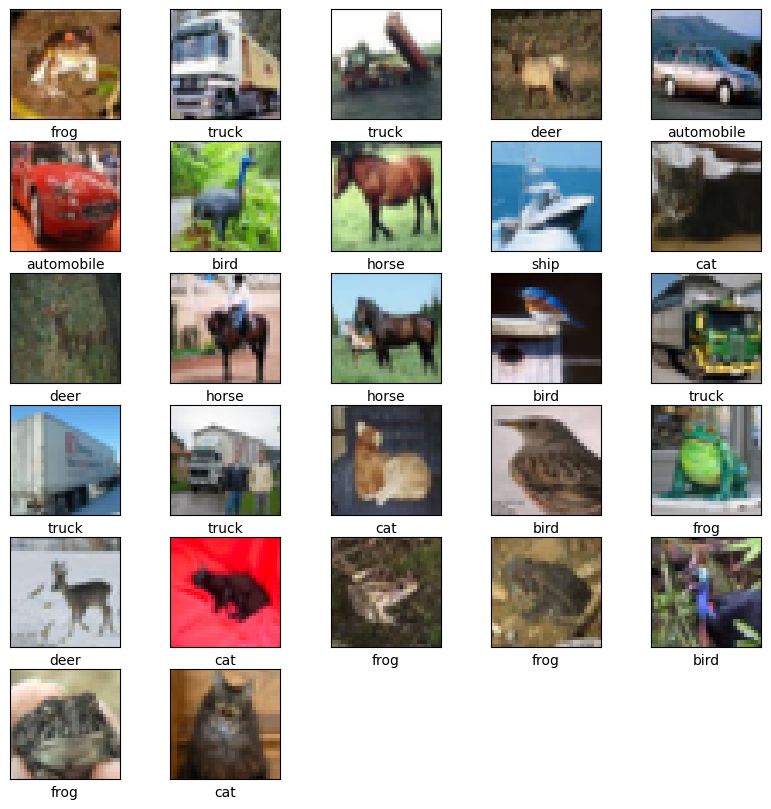

In [ ]:
# Visualize some of the classes in accordance with the training dataset
plt.figure(figsize=[10,10])
for i in range (27):    # for first 25 images
  plt.subplot(6, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(X_train[i], cmap=plt.cm.binary)
  plt.xlabel(class_names[y_train[i][0]])

plt.show()

## Data Preprocessing

- The reason for Normalizing is to convert all pixel values to values between 0 and 1.
- The reason for converting type to float is that to_categorical (one hot encoding) needs the data to be of type float by default.
- The reason for using to_categorical is that the loss function that we will be using in this code (categorical_crossentropy) when compiling the model needs data to be one hot encoded.


In [ ]:
# Now, convert the pixels data to float type
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Normalization (255 is the total number of pixels an image can have)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Transform target variable into one-hotencoding
from keras.utils import to_categorical
y_cat_train = to_categorical(y_train, 10)
y_cat_test = to_categorical(y_test, 10)

In [ ]:
y_cat_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

## Model Building

Model buildig is always a 3 step job in NN

- **Define the layers** ; means - schema to be mentioned, details regarding the layers to be mentioned

- **Compile the model** : means - You will mention and define the calculations for training as well for testing (performance evaluation)

- **Train the model**: mean - you will insert the input data to get that trained

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout

In [ ]:
# Create a sequential model and add layers to it
model = Sequential()

# Convolutional Layer
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))

# 32*32 specifies the height and width of the input image, and 3 specifies the RGB channel (Red, Green, and Blue).
# 32 is the total number of filters we are using, and 3*3 the dimension of each filter.
# We are using relu activation function and add padding as we don't want to reduce the size.

#________ ADDITIONAL DETAILING _______________

#2 covl layers to add, more layers, more the complexity

#Filters — It refers to the number of filters to be applied in the convolution,32 or 64

#Kernel_size — It refers to the length of the convolution window. Eg. (3,3) or (4,4).

#input_shape is 32, 32 and height and width of input image and 3 specifies RGB(color)

#input shape is what flows between layers are tensors. Tensors can be seen as matrices, with shapes.

#if you have 30 images of 50x50 pixels in RGB (3 channels), the shape of your input data is (30,50,50,3)

#activation -refers to the regularizer function, relu is most popular

#“padding = same” this means that padding will be applied to the image or zeros will be added to the image
#model.add(Conv2D(32))

#output from 1st layer is same as input so the input_shape of 2nd layer will be similar

#______________________________________________________________________________________________________

# Pooling layer
model.add(MaxPool2D(pool_size=(2, 2)))

# Pooling layer is responsible for downsampling and we are taking the dimension as 2*2.

# We train the model with dropout layers with a dropout probability of 35% prevents model from overfitting
model.add(Dropout(0.35))

# 2nd Block
# We increase the no. of filters to 128 in order to get detail information about the image

model.add(Conv2D(filters=128, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(Conv2D(filters=128, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))

# Larger filters allow a CNN to recognize more complex features.
# For example, a small filter may only recognize edges and simple shapes,
# while a larger filter may recognize more complex patterns or even entire objects.


model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.35))

# Flattening Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.35))
model.add(Dense(10, activation='softmax'))

# Apply softmax in the output layer for multiclass classification as we have 10 classes

# Softmax - used for multiclass classification problem(realigns output in much organized),
# returns probability for each class; Sum of probabilities of output incase of
# softmax activation function is 1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Dropout

Dropout is a powerful regularization technique that can significantly reduce overfitting in deep neural networks (DNNs). By randomly dropping out neurons during training, dropout encourages the network to learn more robust representations of the input data

In [ ]:
# Check the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,244,714 (4.75 MB)

 Trainable params: 1,244,714 (4.75 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the Model

- Optimizer used during Back Propagation for weight and bias adjustment - Adam (adjusts the learning rate adaptively).
- Loss Function used - Categorical Crossentropy (used when multiple categories/classes are present).
- Metrics used for evaluation - Accuracy.

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics= ['accuracy'])

## Model Training

Fitting the Model
- Batch Size is used for Adam optimizer.
- Epochs - One epoch is one complete cycle (forward pass + backward pass).

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout

# Creating a sequential model and adding layers to it
model = Sequential()

# Convolutional Layer (1st Block)
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.35))

# 2nd Block
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.35))

# Flattening Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.35))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics= ['accuracy'])

# Train the model
r = model.fit(X_train, y_cat_train, batch_size= 100, epochs = 30, validation_split=0.2)

Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.3663 - loss: 1.7232 - val_accuracy: 0.5281 - val_loss: 1.3013
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5308 - loss: 1.2998 - val_accuracy: 0.5975 - val_loss: 1.1118
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5949 - loss: 1.1364 - val_accuracy: 0.6613 - val_loss: 0.9561
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6380 - loss: 1.0135 - val_accuracy: 0.6930 - val_loss: 0.8700
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6711 - loss: 0.9260 - val_accuracy: 0.7029 - val_loss: 0.8475
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6959 - loss: 0.8619 - val_accuracy: 0.7266 - val_loss: 0.7753
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7166 - loss: 0.8057 - val_accuracy: 0.7386 - val_loss: 0.7456
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7289 - loss: 0.7672 - val_ac

In [ ]:
# from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True
# )

# history = model.fit(
#     X_train,
#     y_train,
#     epochs=50,
#     validation_split=0.2,
#     callbacks=[early_stop]
# )

## Visualizing the Evaluation
- Loss Curve - Comparing the Training Loss with the Testing Loss over increasing Epochs.
- Accuracy Curve - Comparing the Training Accuracy with the Testing Accuracy over increasing Epochs.

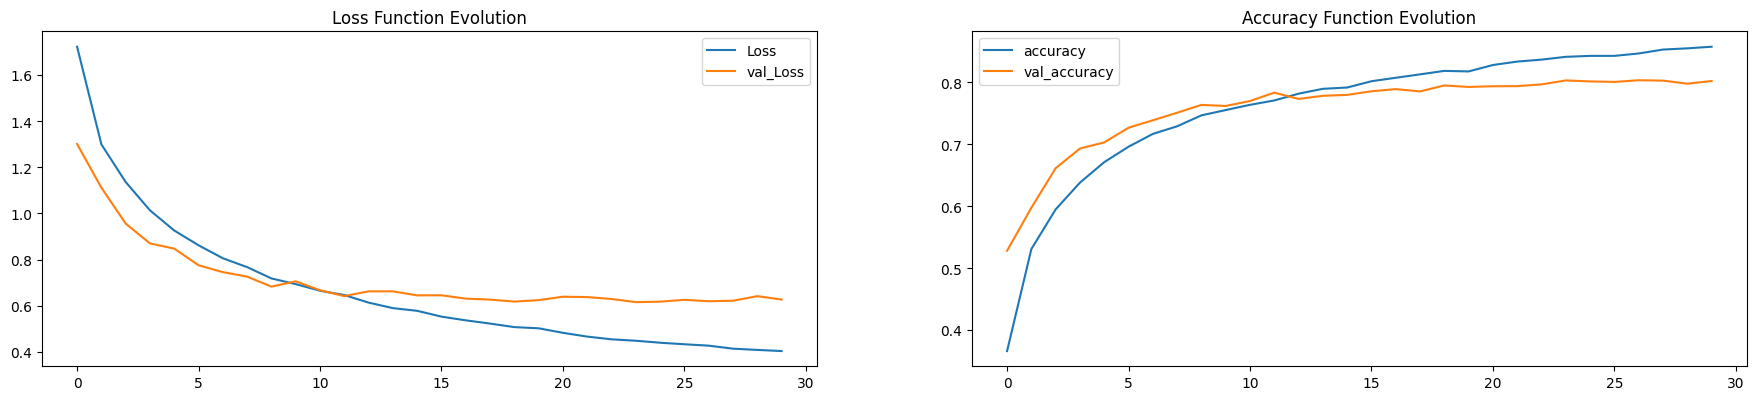

In [ ]:
plt.figure(figsize=(22, 20))

plt.subplot(4, 2, 1)
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='val_Loss')
plt.title('Loss Function Evolution')
plt.legend()

plt.subplot(4, 2, 2)
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Function Evolution')
plt.legend()

## Evaluate the performance of CNN model on test data

In [ ]:
score = model.evaluate(X_test, y_cat_test)
print('Test Loss: ', score[0])
print(f'Test Accuracy : {score[1] * 100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7966 - loss: 0.6525
Test Loss:  0.6524812579154968
Test Accuracy : 79.66%


In [ ]:
# Make Prediction
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


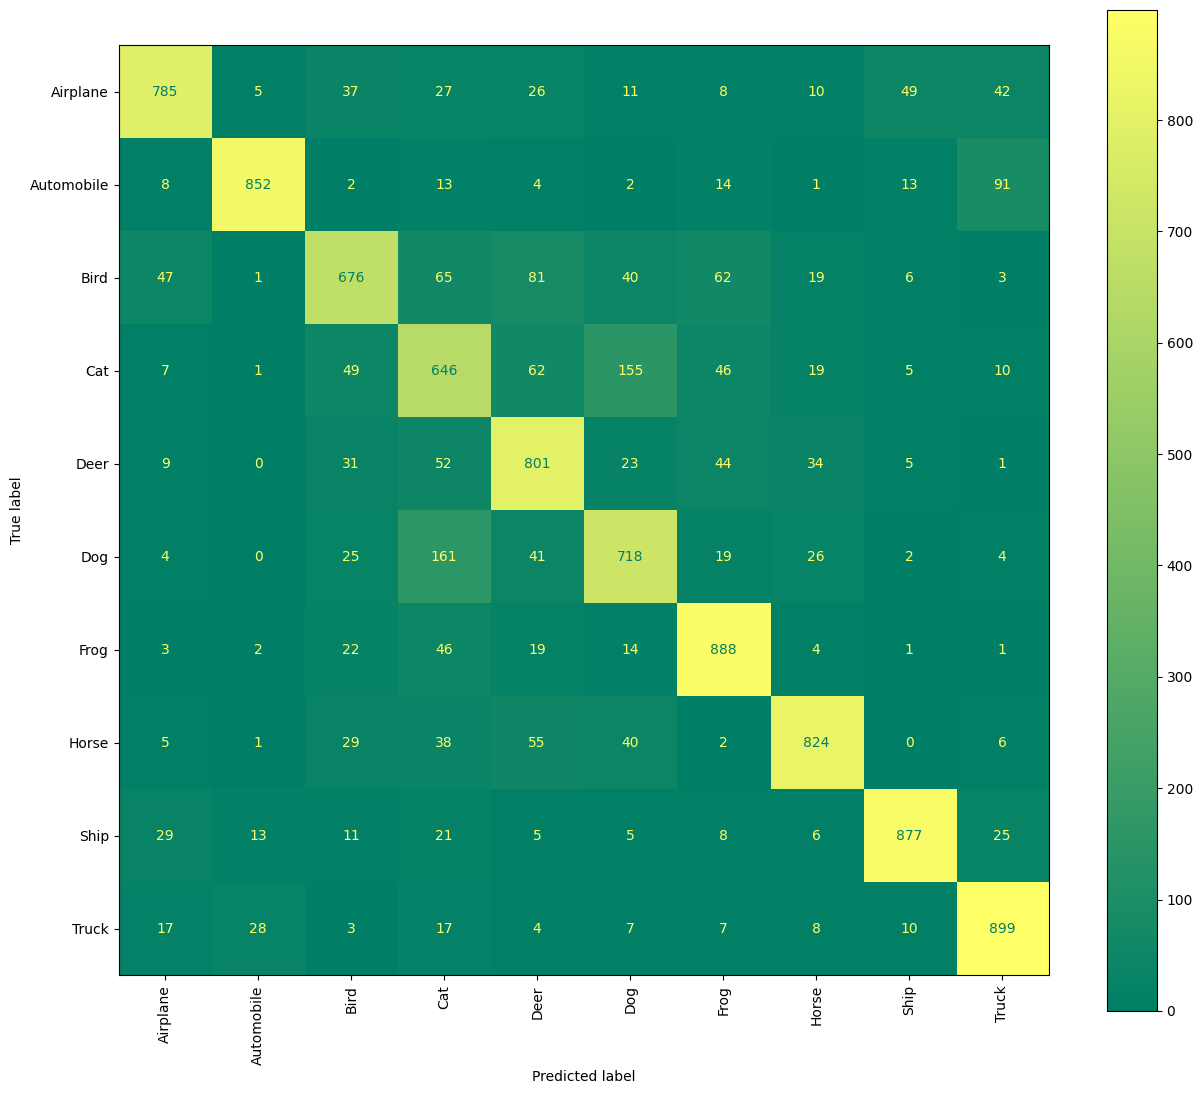

In [ ]:
# Plot the confusion matrix
labels = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=labels)

# NOTE: Fill all variables here with default values of the plot_confusion_matrix
fig, ax = plt.subplots(figsize=(15, 13))
disp = disp.plot(xticks_rotation='vertical', ax=ax,cmap='summer')

plt.show()

Final Execution - Load CIFAR-10 Dataset and Print them all

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)

Image dtype: uint8
Pixel value range: 0 to 255

Class distribution:
airplane: 5000 samples
automobile: 5000 samples
bird: 5000 samples
cat: 5000 samples
deer: 5000 samples
dog: 5000 samples
frog: 5000 samples
horse: 5000 samples
ship: 5000 samples
truck: 5000 samples


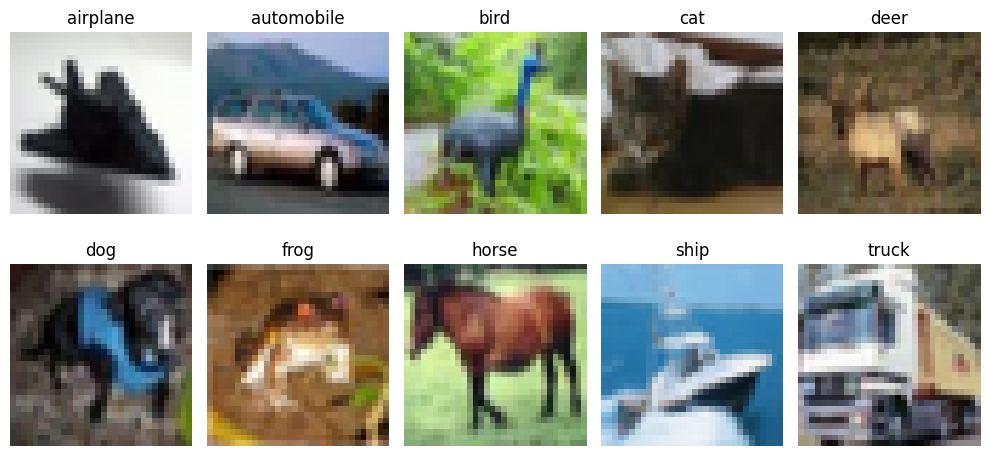

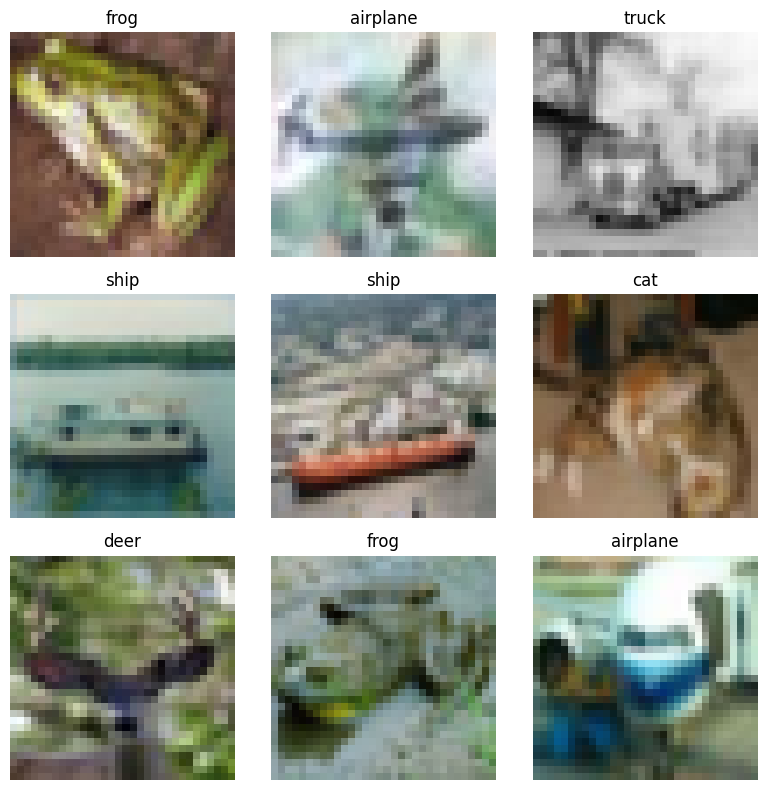

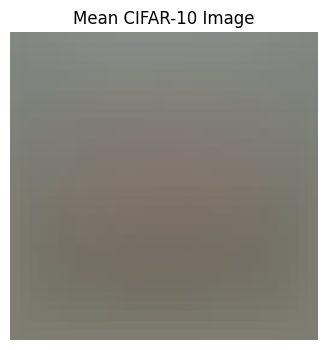


After normalisation:
Pixel range: 0.0 to 1.0


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


# 1. Basic dataset inspection
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

# 2. Data types and pixel range
print("\nImage dtype:", x_train.dtype)
print("Pixel value range:", x_train.min(), "to", x_train.max())

# 3. Class distribution
unique, counts = np.unique(y_train, return_counts=True)

print("\nClass distribution:")
for i, count in zip(unique, counts):
    print(f"{class_names[i]}: {count} samples")

# 4. Visualise sample images (one per class)
plt.figure(figsize=(10, 5))

for i in range(10):
    idx = np.where(y_train.flatten() == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx])
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 5. Random image grid
plt.figure(figsize=(8, 8))

for i in range(9):
    idx = np.random.randint(0, x_train.shape[0])
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[idx])
    plt.title(class_names[y_train[idx][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 6. Mean image (dataset-level structure)
mean_image = x_train.mean(axis=0).astype("uint8")

plt.figure(figsize=(4, 4))
plt.imshow(mean_image)
plt.title("Mean CIFAR-10 Image")
plt.axis("off")
plt.show()

# 7. Normalisation check
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

print("\nAfter normalisation:")
print("Pixel range:", x_train_norm.min(), "to", x_train_norm.max())
